# 2110742 Evolutionary Computation
## Final Project: Simplified UAV Path Planning

This notebook presents an simple experiment for **2D UAV path planning** using evolutionary computation.

### Main goal
Compare:
- **Single-objective Genetic Algorithm (GA)** using a weighted-sum objective
- **NSGA-II** for true multi-objective optimization

### Problem setting
A UAV must travel from a start point to a goal point in a 2D map with circular obstacles.

### Evaluation criteria
- Path length
- Risk near obstacles
- Collision count

In [1]:
!pip install numpy matplotlib pymoo

   ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
   ---------------------------------------- 1.9/1.9 MB 12.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   --- ------------------------------------ 3.4/37.3 MB 16.1 MB/s eta 0:00:03
   ----- ---------------------------------- 5.0/37.3 MB 12.4 MB/s eta 0:00:03
   ------- -------------------------------- 6.6/37.3 MB 10.7 MB/s eta 0:00:03
   --------- ------------------------------ 8.7/37.3 MB 10.9 MB/s eta 0:00:03
   ----------- ---------------------------- 10.7/37.3 MB 10.5 MB/s eta 0:00:03
   --------------- ------------------------ 14.2/37.3 MB 11.5 MB/s eta 0:00:03
   ----------------- ---------------------- 16.8/37.3 MB 11.7 MB/s eta 0:00:02
   --------------------- ------------------ 20.2/37.3 MB 12.3 MB/s eta 0:00:02
   ------------------------ --------------- 22.5/37.3 MB 12.2 MB/s eta 0:00:02
   -------------------------- ------------- 24.9/37.3 MB 12.1 MB/s eta 0:00:0


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports

In [2]:
from __future__ import annotations

from dataclasses import dataclass
import math
from typing import List, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pymoo.core.problem import ElementwiseProblem
from pymoo.core.repair import Repair
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.optimize import minimize

Point = Tuple[float, float]

## 2. Environment definition

In [3]:
@dataclass(frozen=True)
class CircleObstacle:
    cx: float
    cy: float
    radius: float

    def contains(self, x: float, y: float) -> bool:
        return (x - self.cx) ** 2 + (y - self.cy) ** 2 <= self.radius ** 2


@dataclass(frozen=True)
class MapConfig:
    size: float = 100.0
    start: Point = (5.0, 5.0)
    goal: Point = (95.0, 95.0)
    n_waypoints: int = 8
    danger_margin: float = 5.0
    obstacles: Tuple[CircleObstacle, ...] = (
        CircleObstacle(30, 30, 10),
        CircleObstacle(60, 20, 8),
        CircleObstacle(50, 50, 12),
        CircleObstacle(20, 70, 9),
        CircleObstacle(75, 60, 10),
        CircleObstacle(40, 85, 7),
        CircleObstacle(85, 35, 8),
        CircleObstacle(65, 80, 6),
        CircleObstacle(15, 45, 6),
        CircleObstacle(55, 10, 5),
        CircleObstacle(80, 80, 7),
        CircleObstacle(35, 60, 8),
    )

config = MapConfig()
config

MapConfig(size=100.0, start=(5.0, 5.0), goal=(95.0, 95.0), n_waypoints=8, danger_margin=5.0, obstacles=(CircleObstacle(cx=30, cy=30, radius=10), CircleObstacle(cx=60, cy=20, radius=8), CircleObstacle(cx=50, cy=50, radius=12), CircleObstacle(cx=20, cy=70, radius=9), CircleObstacle(cx=75, cy=60, radius=10), CircleObstacle(cx=40, cy=85, radius=7), CircleObstacle(cx=85, cy=35, radius=8), CircleObstacle(cx=65, cy=80, radius=6), CircleObstacle(cx=15, cy=45, radius=6), CircleObstacle(cx=55, cy=10, radius=5), CircleObstacle(cx=80, cy=80, radius=7), CircleObstacle(cx=35, cy=60, radius=8)))

## 3. Geometry helpers and path metrics

In [4]:
def sample_segment(p1: Point, p2: Point, n: int = 25) -> np.ndarray:
    xs = np.linspace(p1[0], p2[0], n)
    ys = np.linspace(p1[1], p2[1], n)
    return np.column_stack([xs, ys])


def point_to_obstacle_surface_distance(x: float, y: float, obstacle: CircleObstacle) -> float:
    return math.hypot(x - obstacle.cx, y - obstacle.cy) - obstacle.radius


def min_surface_distance(x: float, y: float, obstacles: Sequence[CircleObstacle]) -> float:
    return min(point_to_obstacle_surface_distance(x, y, obs) for obs in obstacles)


def segment_collision_count(p1: Point, p2: Point, obstacles: Sequence[CircleObstacle], n: int = 25) -> int:
    count = 0
    for x, y in sample_segment(p1, p2, n):
        if any(obs.contains(float(x), float(y)) for obs in obstacles):
            count += 1
    return count


def segment_risk(p1: Point, p2: Point, obstacles: Sequence[CircleObstacle], danger_margin: float, n: int = 25) -> float:
    total = 0.0
    for x, y in sample_segment(p1, p2, n):
        d = min_surface_distance(float(x), float(y), obstacles)
        if d < 0:
            total += 10.0
        elif d < danger_margin:
            total += (danger_margin - d) / danger_margin
    return total / n


def decode_solution(x: np.ndarray, config: MapConfig) -> List[Point]:
    pts = [config.start]
    for i in range(config.n_waypoints):
        pts.append((float(x[2 * i]), float(x[2 * i + 1])))
    pts.append(config.goal)
    return pts


def path_length(path: Sequence[Point]) -> float:
    return sum(
        math.hypot(path[i + 1][0] - path[i][0], path[i + 1][1] - path[i][1])
        for i in range(len(path) - 1)
    )


def path_collision_count(path: Sequence[Point], obstacles: Sequence[CircleObstacle]) -> int:
    return sum(segment_collision_count(path[i], path[i + 1], obstacles) for i in range(len(path) - 1))


def path_risk(path: Sequence[Point], obstacles: Sequence[CircleObstacle], danger_margin: float) -> float:
    return sum(segment_risk(path[i], path[i + 1], obstacles, danger_margin) for i in range(len(path) - 1))

## 4. Plot function

In [5]:
def plot_environment(ax, config: MapConfig, path: Sequence[Point] | None = None, title: str = ""):
    ax.set_xlim(0, config.size)
    ax.set_ylim(0, config.size)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

    for obs in config.obstacles:
        danger = plt.Circle((obs.cx, obs.cy), obs.radius + config.danger_margin, color="orange", alpha=0.10)
        body = plt.Circle((obs.cx, obs.cy), obs.radius, color="red", alpha=0.35)
        ax.add_patch(danger)
        ax.add_patch(body)

    ax.plot(config.start[0], config.start[1], marker="s", markersize=10, color="green", label="Start")
    ax.plot(config.goal[0], config.goal[1], marker="*", markersize=14, color="red", label="Goal")

    if path is not None:
        xs = [p[0] for p in path]
        ys = [p[1] for p in path]
        ax.plot(xs, ys, marker="o", linewidth=2)

    ax.legend(loc="upper left")

## 5. Optional repair operator

In [6]:
class ObstacleAwareRepair(Repair):
    def __init__(self, config: MapConfig, push_eps: float = 1.5):
        super().__init__()
        self.config = config
        self.push_eps = push_eps

    def _do(self, problem, X, **kwargs):
        X = np.copy(X)

        for row in range(len(X)):
            X[row] = np.clip(X[row], 0.0, self.config.size)

            for i in range(0, len(X[row]), 2):
                px, py = float(X[row][i]), float(X[row][i + 1])

                for obs in self.config.obstacles:
                    dx = px - obs.cx
                    dy = py - obs.cy
                    dist = math.hypot(dx, dy)

                    if dist < obs.radius + self.push_eps:
                        if dist < 1e-9:
                            dx, dy = 1.0, 0.0
                            dist = 1.0

                        scale = (obs.radius + self.push_eps) / dist
                        px = obs.cx + dx * scale
                        py = obs.cy + dy * scale

                X[row][i] = np.clip(px, 0.0, self.config.size)
                X[row][i + 1] = np.clip(py, 0.0, self.config.size)

        return X

## 6. Optimization problems

In [7]:
class WeightedPathPlanningProblem(ElementwiseProblem):
    def __init__(self, config: MapConfig, w_length=1.0, w_risk=50.0, w_collision=200.0):
        self.config = config
        self.w_length = w_length
        self.w_risk = w_risk
        self.w_collision = w_collision

        super().__init__(
            n_var=2 * config.n_waypoints,
            n_obj=1,
            n_ieq_constr=0,
            xl=np.zeros(2 * config.n_waypoints),
            xu=np.full(2 * config.n_waypoints, config.size),
        )

    def _evaluate(self, x, out, *args, **kwargs):
        path = decode_solution(x, self.config)
        f_length = path_length(path)
        f_risk = path_risk(path, self.config.obstacles, self.config.danger_margin)
        f_collision = path_collision_count(path, self.config.obstacles)

        out["F"] = [self.w_length * f_length + self.w_risk * f_risk + self.w_collision * f_collision]


class MultiObjectivePathPlanningProblem(ElementwiseProblem):
    def __init__(self, config: MapConfig):
        self.config = config

        super().__init__(
            n_var=2 * config.n_waypoints,
            n_obj=3,
            n_ieq_constr=0,
            xl=np.zeros(2 * config.n_waypoints),
            xu=np.full(2 * config.n_waypoints, config.size),
        )

    def _evaluate(self, x, out, *args, **kwargs):
        path = decode_solution(x, self.config)
        f1 = path_length(path)
        f2 = path_risk(path, self.config.obstacles, self.config.danger_margin)
        f3 = float(path_collision_count(path, self.config.obstacles))
        out["F"] = [f1, f2, f3]

## 7. Runner functions

In [8]:
def make_real_operators(n_var: int):
    return dict(
        sampling=FloatRandomSampling(),
        crossover=SBX(prob=0.9, eta=15),
        mutation=PM(prob=1.0 / n_var, eta=20),
    )


def run_ga(config: MapConfig, seed: int = 42, use_repair: bool = False):
    problem = WeightedPathPlanningProblem(config)
    repair = ObstacleAwareRepair(config) if use_repair else None
    operators = make_real_operators(problem.n_var)

    algorithm = GA(pop_size=80, repair=repair, **operators)

    return minimize(
        problem,
        algorithm,
        termination=("n_gen", 80),
        seed=seed,
        save_history=True,
        verbose=False,
    )


def run_nsga2(config: MapConfig, seed: int = 42, use_repair: bool = False):
    problem = MultiObjectivePathPlanningProblem(config)
    repair = ObstacleAwareRepair(config) if use_repair else None
    operators = make_real_operators(problem.n_var)

    algorithm = NSGA2(pop_size=80, repair=repair, **operators)

    return minimize(
        problem,
        algorithm,
        termination=("n_gen", 80),
        seed=seed,
        save_history=True,
        verbose=False,
    )


def weighted_score_from_objectives(obj: np.ndarray, w=(1.0, 50.0, 200.0)) -> float:
    return w[0] * obj[0] + w[1] * obj[1] + w[2] * obj[2]


def pick_compromise_from_pareto(X: np.ndarray, F: np.ndarray):
    idx = min(range(len(F)), key=lambda i: weighted_score_from_objectives(F[i]))
    return X[idx], F[idx]

## 8. Run the experiment once

In [9]:
ga_res = run_ga(config, seed=42, use_repair=False)
nsga_res = run_nsga2(config, seed=42, use_repair=False)

ga_x = np.atleast_2d(ga_res.X)[0]
ga_path = decode_solution(ga_x, config)

X = np.atleast_2d(nsga_res.X)
F = np.atleast_2d(nsga_res.F)
best_x, best_f = pick_compromise_from_pareto(X, F)
nsga_path = decode_solution(best_x, config)

print("GA")
print("  length     =", path_length(ga_path))
print("  risk       =", path_risk(ga_path, config.obstacles, config.danger_margin))
print("  collisions =", path_collision_count(ga_path, config.obstacles))

print("\nNSGA-II compromise solution")
print("  length     =", best_f[0])
print("  risk       =", best_f[1])
print("  collisions =", best_f[2])
print("  pareto size=", len(F))

GA
  length     = 170.70813257099456
  risk       = 0.010608921540883115
  collisions = 0

NSGA-II compromise solution
  length     = 180.29407818905332
  risk       = 0.02523052576163747
  collisions = 0.0
  pareto size= 64


## 9. Visual comparison of paths

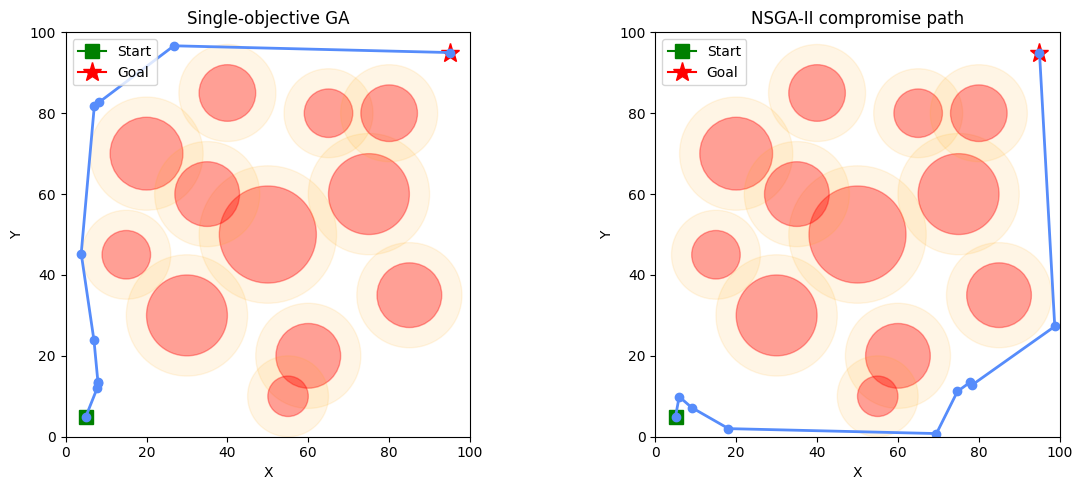

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_environment(axes[0], config, ga_path, "Single-objective GA")
plot_environment(axes[1], config, nsga_path, "NSGA-II compromise path")
plt.tight_layout()
plt.show()

## 10. Pareto front

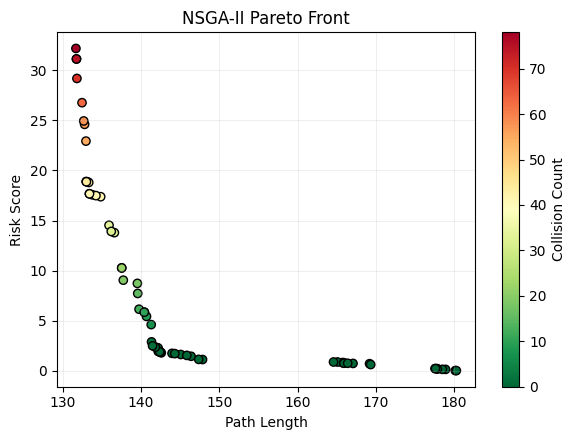

In [11]:
plt.figure(figsize=(6, 4.5))
plt.scatter(F[:, 0], F[:, 1], c=F[:, 2], cmap="RdYlGn_r", edgecolors="black")
plt.xlabel("Path Length")
plt.ylabel("Risk Score")
plt.title("NSGA-II Pareto Front")
cb = plt.colorbar()
cb.set_label("Collision Count")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Convergence comparison

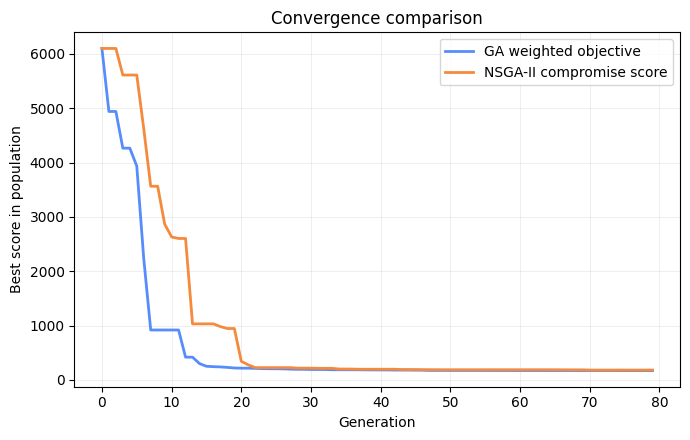

In [12]:
def extract_ga_history(res):
    vals = []
    for algo in res.history:
        F = algo.pop.get("F")
        vals.append(np.min(F[:, 0]))
    return np.array(vals)


def extract_nsga_history(res):
    vals = []
    for algo in res.history:
        F = algo.pop.get("F")
        scores = [weighted_score_from_objectives(f) for f in F]
        vals.append(np.min(scores))
    return np.array(vals)


ga_hist = extract_ga_history(ga_res)
nsga_hist = extract_nsga_history(nsga_res)

plt.figure(figsize=(7, 4.5))
plt.plot(ga_hist, label="GA weighted objective", linewidth=2)
plt.plot(nsga_hist, label="NSGA-II compromise score", linewidth=2)
plt.xlabel("Generation")
plt.ylabel("Best score in population")
plt.title("Convergence comparison")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 12. Multi-run summary

In [13]:
def run_multi_seed(config: MapConfig, seeds=range(5), use_repair=False):
    rows = []

    for seed in seeds:
        ga_res = run_ga(config, seed=seed, use_repair=use_repair)
        ga_path = decode_solution(np.atleast_2d(ga_res.X)[0], config)

        nsga_res = run_nsga2(config, seed=seed, use_repair=use_repair)
        X = np.atleast_2d(nsga_res.X)
        F = np.atleast_2d(nsga_res.F)
        best_x, best_f = pick_compromise_from_pareto(X, F)

        rows.append({
            "seed": seed,
            "ga_length": path_length(ga_path),
            "ga_risk": path_risk(ga_path, config.obstacles, config.danger_margin),
            "ga_collisions": path_collision_count(ga_path, config.obstacles),
            "nsga_length": best_f[0],
            "nsga_risk": best_f[1],
            "nsga_collisions": best_f[2],
            "pareto_size": len(F),
        })

    return pd.DataFrame(rows)


df = run_multi_seed(config, seeds=range(5), use_repair=False)
df

,seed,ga_length,ga_risk,ga_collisions,nsga_length,nsga_risk,nsga_collisions,pareto_size
0,0,212.788017,0.020590,0,144.658182,0.125175,0.0,60
1,1,175.911809,0.000000,0,147.838146,0.249877,0.0,33
2,2,176.593731,0.036047,0,165.133527,1.290012,0.0,80
3,3,149.248858,0.086814,0,177.201788,0.172217,0.0,80
4,4,241.244190,0.249439,0,142.221011,0.298504,0.0,52


In [14]:
df.describe()

,seed,ga_length,ga_risk,ga_collisions,nsga_length,nsga_risk,nsga_collisions,pareto_size
count,5.000000,5.000000,5.000000,5.0,5.000000,5.000000,5.0,5.000000
mean,2.000000,191.157321,0.078578,0.0,155.410531,0.427157,0.0,61.000000
std,1.581139,35.977161,0.100756,0.0,15.135331,0.487002,0.0,19.924859
min,0.000000,149.248858,0.000000,0.0,142.221011,0.125175,0.0,33.000000
25%,1.000000,175.911809,0.020590,0.0,144.658182,0.172217,0.0,52.000000
50%,2.000000,176.593731,0.036047,0.0,147.838146,0.249877,0.0,60.000000
75%,3.000000,212.788017,0.086814,0.0,165.133527,0.298504,0.0,80.000000
max,4.000000,241.244190,0.249439,0.0,177.201788,1.290012,0.0,80.000000


C:\Users\crafts\AppData\Local\Temp\ipykernel_34864\833709661.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([df["ga_length"], df["nsga_length"]], labels=["GA", "NSGA-II"], patch_artist=True)
C:\Users\crafts\AppData\Local\Temp\ipykernel_34864\833709661.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df["ga_risk"], df["nsga_risk"]], labels=["GA", "NSGA-II"], patch_artist=True)
C:\Users\crafts\AppData\Local\Temp\ipykernel_34864\833709661.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot([df["ga_collisions"], df["nsga_collisions"]], labels=["GA", "NSGA-II"], pat

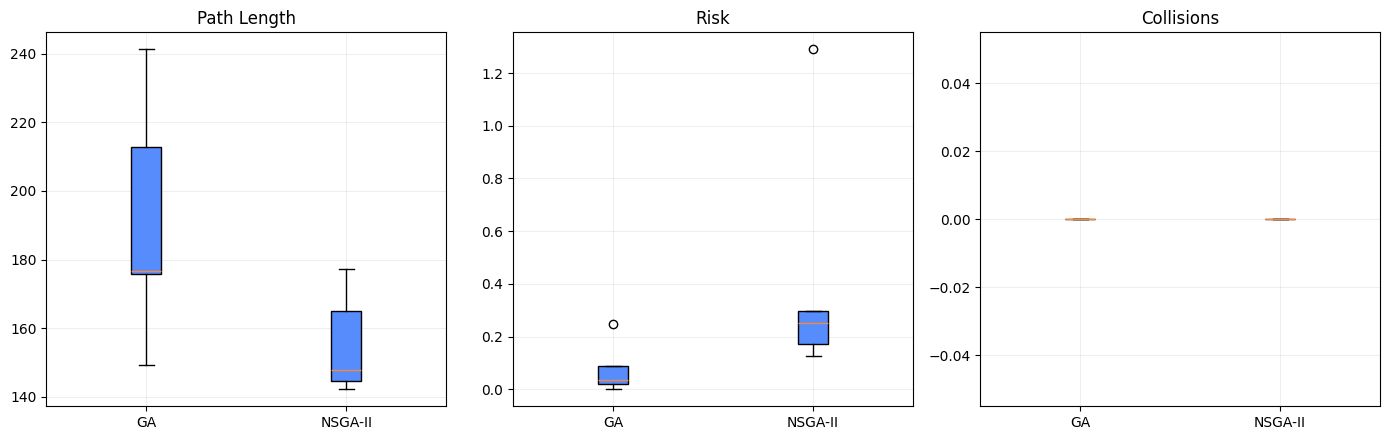

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

axes[0].boxplot([df["ga_length"], df["nsga_length"]], labels=["GA", "NSGA-II"], patch_artist=True)
axes[0].set_title("Path Length")
axes[0].grid(alpha=0.3)

axes[1].boxplot([df["ga_risk"], df["nsga_risk"]], labels=["GA", "NSGA-II"], patch_artist=True)
axes[1].set_title("Risk")
axes[1].grid(alpha=0.3)

axes[2].boxplot([df["ga_collisions"], df["nsga_collisions"]], labels=["GA", "NSGA-II"], patch_artist=True)
axes[2].set_title("Collisions")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Optional extension: enable repair operator

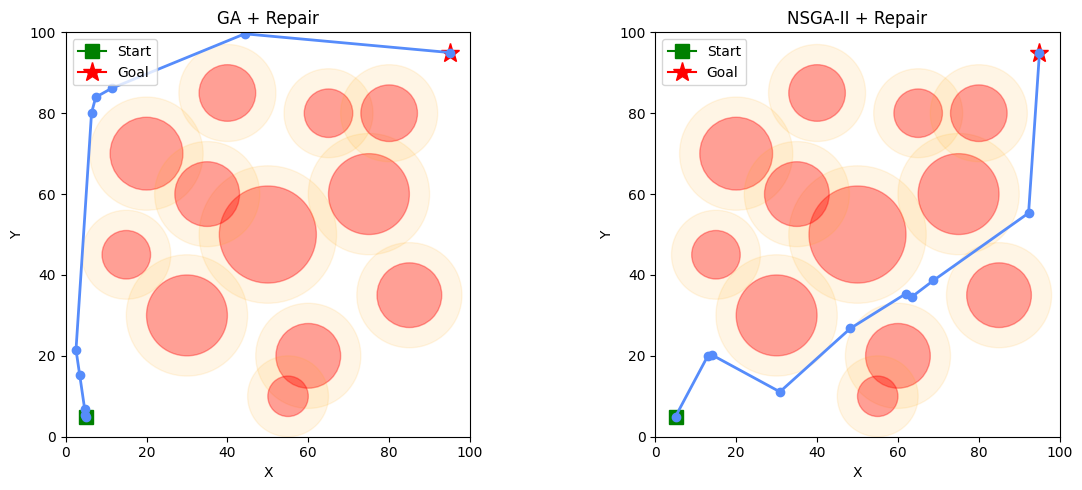

NSGA-II + Repair compromise objectives = [153.79287163   0.17098194   0.        ]
Pareto set size with repair            = 80


In [16]:
ga_res_r = run_ga(config, seed=42, use_repair=True)
nsga_res_r = run_nsga2(config, seed=42, use_repair=True)

ga_path_r = decode_solution(np.atleast_2d(ga_res_r.X)[0], config)

Xr = np.atleast_2d(nsga_res_r.X)
Fr = np.atleast_2d(nsga_res_r.F)
best_xr, best_fr = pick_compromise_from_pareto(Xr, Fr)
nsga_path_r = decode_solution(best_xr, config)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_environment(axes[0], config, ga_path_r, "GA + Repair")
plot_environment(axes[1], config, nsga_path_r, "NSGA-II + Repair")
plt.tight_layout()
plt.show()

print("NSGA-II + Repair compromise objectives =", best_fr)
print("Pareto set size with repair            =", len(Fr))

## 14. Conclusion

This notebook shows a compact evolutionary computation experiment for simplified UAV path planning.

Main points:
- **GA** provides a single answer using a weighted objective.
- **NSGA-II** returns a Pareto set and is more suitable when objectives conflict.